# **FastAPI**


* FastAPI is a modern, fast , web framework for building APIs with Python.
                       * Fast(Performance)
                       * Fast(Development)

* **Key Features :**
    * One of the Fastest Python Frameworks available.
    * Fast --> Very High Performance.
    * Fewer bugs --> Reduce about 40% of human induced errors.
    * Easy --> Designed to be easy to use and learn.

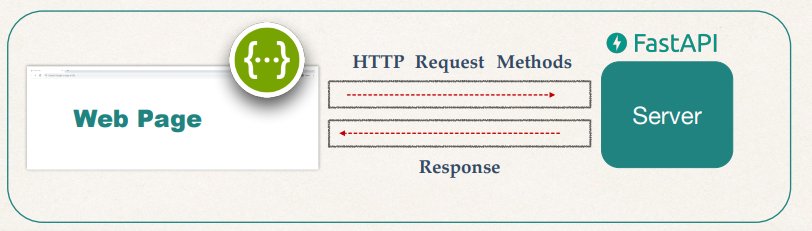

**In this Documentation, we will learn**

1. Initial Steps to work with FastAPI.
              * Installation of FastAPI.
              * Installation of Uvicorn Server.
              * Simplest FastAPI File (Hello World).
              * Running the Live server.
              * Playing with Interactive API (Swagger UI).
2. Path Parameters.
              * Static Path Parameters.
              * Dynamic Path Parameters.
3. Query Parameters.
4. Basic CRUD operations.
              * Get Operation.
              * Post Operation.
              * Put Operation.
              * Delete Operation.
5. Validations
              * Path Parameters Validation.
              * Query Parameters Validation.
              * Annotation
6. Pydantic Models.
              * Request Body
7. Field Parameters.
8. Body Parameters.
9. Files.
              * File Parameters
              * File and UploadFile.
              * Working with File content.
10. Integration with LLM’s.
11. Status Codes.

**Note :** This is just a documentation to refer. These are unable to run in collab. Kindly run these in Visual Studio code.You can refer to shared Python file.
* I have shared a Python file along with this Documentation named fast.py .
* Execute this file and work with FastAPI .

# **Initial Steps**

* Installation of FastAPI.
* Installation of Uvicorn Server.
* Simplest FastAPI File (Hello World).
* Running the Live server.
* Playing with Interactive API (Swagger UI).


**Installation of FastAPI**

In [ ]:
!pip install fastapi

**Installation of Uvicorn Server**
* Install uvicorn to work as server that runs the code.

In [7]:
!pip install "uvicorn[standard]"


[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


**Simplest FastAPI File**

FastAPI is a Python class that provides all the functionality for your API.

In [2]:
from fastapi import FastAPI

'app' variable will be instance of class Fastapi.

In [4]:
new = FastAPI()


Below, is the Path Operation Function :
Here ,
* Path  --> ("/hello")  --> Last part of URL
* Operation  --> get --> HTTP Method.
* @app.get("/hello") --> is a path operation decorator which adds an additional functionality to function root(), where 'app' is instance.
* Path ("/hello") Operation (get) Function (root()).
* These will be understood later in this documentation.

In [9]:
@app.get("/hello")
async def root():
    return {"message": "Hello World"}

In [ ]:
# In a single cell
from fastapi import FastAPI

app = FastAPI()

@app.get("/hello")
async def root():
    return {"message": "Hello World"}
#Save this file as Hello.py

**Running the Live server**

* hello --> the file hello.py
* app  --> the object created inside of hello.py with the line app = FastAPI().
* --reload --> make the server restart after code changes.

In [10]:
uvicorn hello:new --reload

SyntaxError: invalid syntax (3102320409.py, line 1)

* Run the above line in the terminal (inside the hello.py file folder ) and it starts the server, provides this output as
* INFO:     Uvicorn running on http://127.0.0.1:8000 (Press CTRL+C to quit)

Open your browser at http://127.0.0.1:8000
* You will see the JSON response as:
* **{"message": "Hello World"}**

**Playing with Interactive API (Swagger UI)**
* You will see the interactive API at http://127.0.0.1:8000/docs
* The Operations we created will be displayed there and We can just click on it and Click "Try it out" and provide the input if required and get the response for that along with status codes.

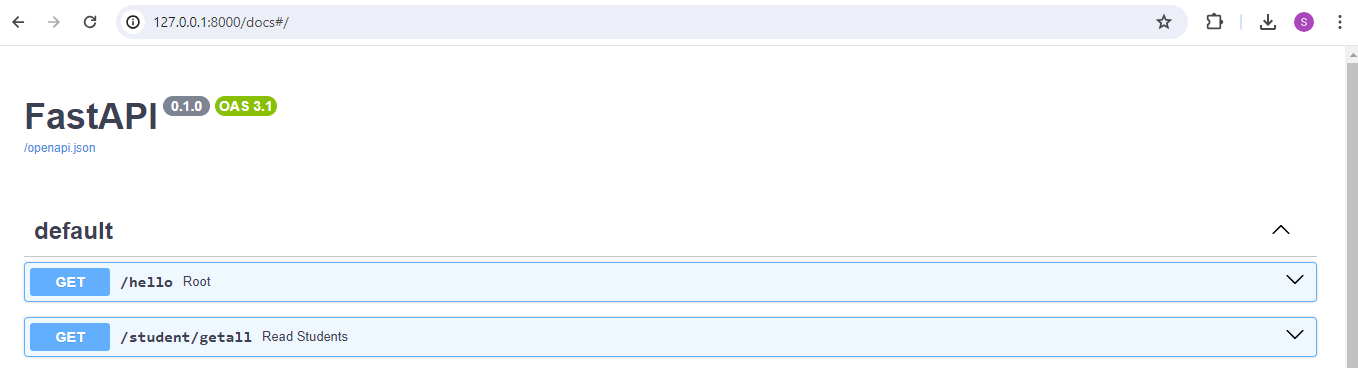

# **Path Parameters**

You can declare path parameters with the same syntax used by Python format strings like {}.
* Two Types of Path Parameters are :
            * Static
            * Dynamic

* To perform the operations , Let us take an example list Students (List of Dictionaries)

In [ ]:
Students = [
    {
        "student_name":"Harry","student_id" : 1,"marks" : 90,"language" : "Python"
    },
    {
        "student_name":"Suzie","student_id" : 2,"marks" :80 ,"language" : "JAVA"
    },
    {
        "student_name":"Steve","student_id" : 2,"marks":60,"language" : "Python"
    },
    {
        "student_name":"Kalix","student_id" : 3,"marks": 95,"language" : "SQL"
    }
]

**Static Path Parameters**

Below , we can see "/student/getall" is the static path and it is fixed and it can only be accessed using http://127.0.0.1:8000/student/getall

* You can also view the same using interactive API at
                   http://127.0.0.1:8000/docs.

In [ ]:
@app.get("/student/getall")
async def read_students():

    """
    This Returns All the Students.
    """

    return Students

      For above request,  We get response as
       [
    {
        "student_name":"Harry","student_id" : 1,"marks" : 90,"language" : "Python"
    },
    {
        "student_name":"Suzie","student_id" : 2,"marks" :80 ,"language" : "JAVA"
    },
    {
        "student_name":"Steve","student_id" : 2,"marks":60,"language" : "Python"
    },
    {
        "student_name":"Kalix","student_id" : 3,"marks": 95,"language" : "SQL"
    }
    ]

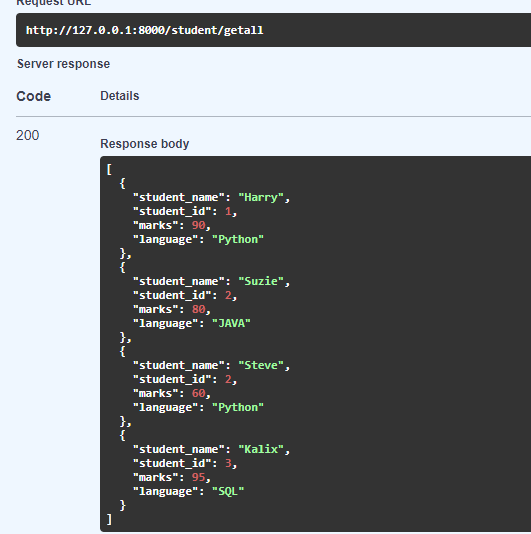

* NOTE : Docstrings can help understand what the function was doing and making use of this is a better practice.

**Dynamic Path Parameters**

Below , we can see "/student/{student_id}" is the dynamic path and it can be changed by our required student id's like 2,3,4,etc..
* For Example , http://127.0.0.1:8000/student/2
* We get the details of Students with student id -> 2
* NOTE : The path parameter needs to be same as in the path.[/{student_id} , so use student_id : int as parameter for the function.

         The response will be {"Student Id" : 2}

* You can also view the same using interactive API at
                   http://127.0.0.1:8000/docs.

In [ ]:
@app.get("/student/{student_id}")
async def get_student(student_id : int):

    """
    This Takes a Student Id and returns the student_id
    """
    return {"Student Id": student_id}

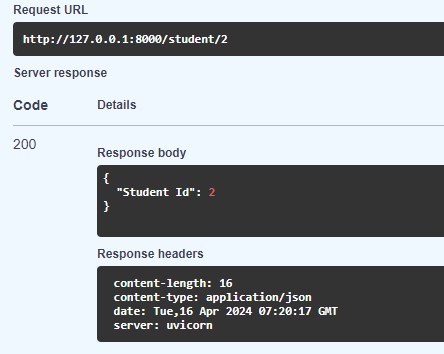

# **Query Parameters**

* Query parameters are the request parameters that have been attached after a "?".
* The query is the set of key-value pairs that go after the ? in a URL, separated by & characters.
* Path parameters are the components of URL path. But Query parameters are optional parameters in the URL.

In [ ]:
@app.get("/students/")
async def read_item(start : int , end :int):

    """
    This Takes a Student Id and returns the student_id
    """

    return Students[start:end]

Below , we can see "/students/" so as per the function we can provide the parameters from url or swagger like
* For Example , http://127.0.0.1:8000/students?1&3
* We get the details of Students from 1-3 index from list.
* Note: "/path/" ending with / will be considered as query parameters.

         The response will be
        [
        {
        "student_name": "Suzie",
        "student_id": 2,
        "marks": 80,
        "language": "JAVA"
         },
        {
         "student_name": "Steve",
         "student_id": 2,
          "marks": 60,
         "language": "Python"
         }
          ]

* You can also view the same using interactive API at
                   http://127.0.0.1:8000/docs.

**Query and Path Parameters**

Below , we can see "/update/{stu_id}/" and it indicates {stud_id} -> path parameter and / at the end represent query parameter so we can use stud_name here as query parameter.
* So as per the function we can provide the parameters from url or swagger like
* For Example , http://127.0.0.1:8000/update/2/Suzie
* We update the student id for all students having student name as Suzie.
* Note: "/path/" ending with / will be considered as query parameters.
       Resposne will be "null" with status code 200.

* You can also view the same using interactive API at
                   http://127.0.0.1:8000/docs.

In [ ]:
@app.put("/update/{stu_id}/")
async def update_student(stu_name : str,stu_id : int):

    """
    This Takes a Student Id and name and update student id  for that name.
    """

    for i in Students:
        if i.get("student_name").casefold() == stu_name.casefold():
            i["student_id"] = stu_id

NOTE : Till now we discussed only the basic concept of Path parameters and query parameters. To learn deep into this please refer [FastAPI Documentation_Parameters](https://fastapi.tiangolo.com/tutorial/query-params/)

# **CRUD Operations**

**CRUD in FastAPI**
* **C**               --> CREATE      --> POST
* **R**               --> READ        --> GET
* **U**               --> UPDATE      --> PUT
* **D**               --> DELETE      --> DELETE

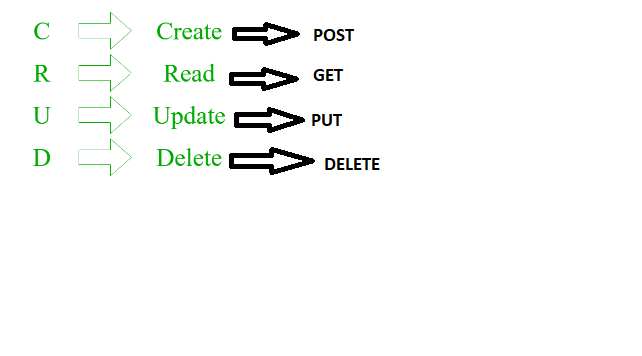

****

**GET Operation in FastAPI**

Below ,
* @app.get() is the GET operation decorator which reads the data from user.
* we can see "/student/getall" is the path and it can be accessed using http://127.0.0.1:8000/student/getall

        So GET operation reads the Students List and provides the data to user.
        
* You can also view the same using interactive API at
                   http://127.0.0.1:8000/docs.

* The response will be :

                For above request,  We get response as
       [
        {
      "student_name":"Harry","student_id" : 1,"marks" : 90,"language" : "Python"
      },
      {
      "student_name":"Suzie","student_id" : 2,"marks" :80 ,"language" : "JAVA"
      },
      {
      "student_name":"Steve","student_id" : 2,"marks":60,"language" : "Python"
      },
      {
      "student_name":"Kalix","student_id" : 3,"marks": 95,"language" : "SQL"
        }
      ]

In [ ]:
@app.get("/student/getall")
async def read_students():

    """
    This Returns All the Students.
    """

    return Students

**POST Operation in FastAPI**

Below ,
* @app.post() is the POST operation decorator which creates the data as required .
* we can see "/student/" is the path and it can be accessed using http://127.0.0.1:8000/student/

        So POST operation creates a new student and adds it to the existing list.
* We used Body() for taking input from the user and here input will be provided in JSON format as
                  {
                    "Student_name":"Jane",
                    "Student_id" : 4,
                    "Marks" : 80,
                    "Language" : "Java"
                  }
        
* You can also view the same using interactive API at
                   http://127.0.0.1:8000/docs.

                Response will be "null" with status code 200.

* Again check the created student using getall() GET request.

In [ ]:
#CREATE
@app.post("/student/")
async def create_book(new = Body()):

    """
    This Takes a dict of an entire students and adds to Students list using Body()
    """

    Students.append(new)

**PUT Operation in FastAPI**

Below ,
* @app.put() is the PUT operation decorator which updates the data as required .
* we can see "/student/" is the path and it can be accessed using http://127.0.0.1:8000/update/

        So Put operation takes the updated JSON and change it in the existing list .
        
* We used Body() for taking input from the user and here input will be provided in JSON format as
                  {
                    "Student_name":"Jane",
                    "Student_id" : 4,
                    "Marks" : 80,
                    "Language" : "Java"
                  }
        
* You can also view the same using interactive API at
                   http://127.0.0.1:8000/docs.

              Response will be "null" with status code 200.

              
* Again check the updated student using getall() GET request.

In [ ]:
#PUT Operation
@app.put("/update/stud_id/marks")
async def update_book(stu_id : int,marks : int):

    """
    This Takes the student_id and updated marks and update that for that specific student based on id.
    """

    for i in Students:
        if i.get("student_id") == stu_id:
            i["marks"] = marks

**DELETE Operation in FastAPI**

Below ,
* @app.delete() is the DELETE operation decorator which deletes the data as required .
* we can see "/delete_me/{stu_name}" is the path and it can be accessed using http://127.0.0.1:8000/delete_me/{stu_name}

        So Delete operation takes the student name and delete all the students with that name from list.

* You can also view the same using interactive API at
                   http://127.0.0.1:8000/docs.

            Response will be "null" with status code 200.
* Again check the updated students list using getall() GET request.

In [ ]:
#DELETE Operation
@app.delete("/delete_me/{stu_name}")
async def delete_student(stu_name: str):

    """
    This Takes a Student name and delete all students with that name.
    """

    for i in range(len(Students)):
        if stu_name.casefold()== Students[i].get("student_name").casefold():
            Students.pop(i)
            break

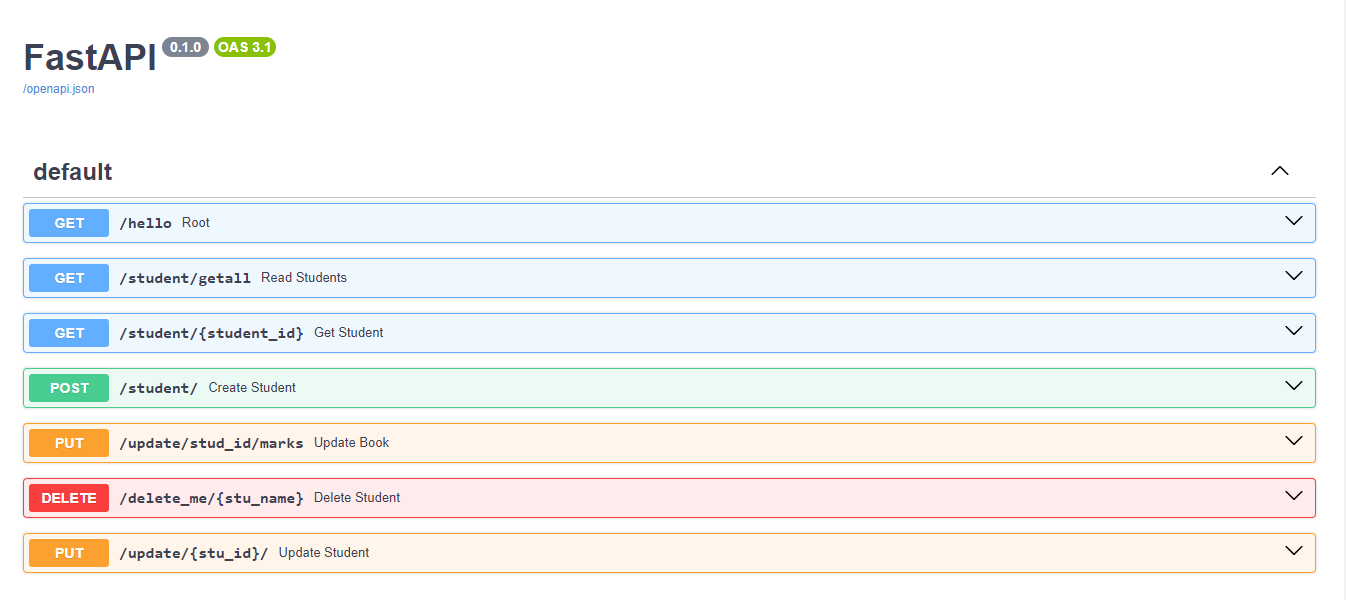

# **Validations**

* FastAPI allows you to declare additional information and validation for your parameters.

**Path Parameter Validations**

* You can declare the validations and metadata for path parameters with Path.
* To achieve that, first import:
              * Path from fastapi
              * Annotated from typing
* Below,
* Path(title="The ID of the student to get",gt=0, le=3) --> This metadata contains title and validations like Id given by user should be greater than 0 and less than 3.

In [ ]:
from typing import Annotated

from fastapi import FastAPI,Path

app = FastAPI()

@app.get("/students/{stu_id}")
async def read_students(stu_id: Annotated[int, Path(title="The ID of the student to get",gt=0, le=3)]):

    """
    This Takes a Student Id and only takes id based on validation and return the id.
    """

    results = {"Student Id": stu_id}
    return results

* **NOTE:**
* item_id: int = Path(title="The ID of the item to get")
* item_id: Annotated[int, Path(title="The ID of the item to get")
* The above both lines defines the same but Prefer to use the Annotated version if possible.

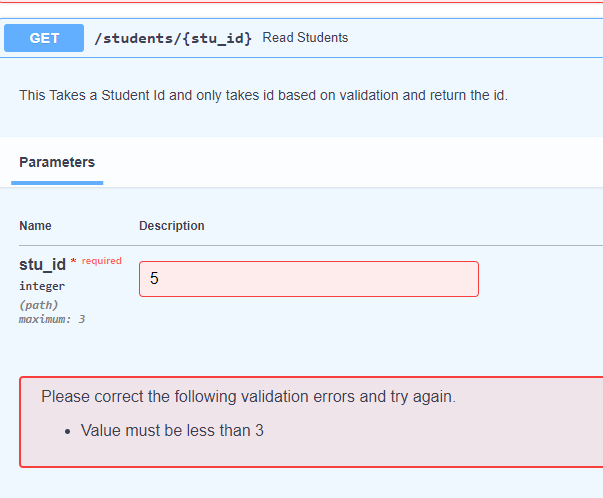

**Query Path Validations**

* Import Query and Annotated.
* To achieve that, first import:
        * Query from fastapi
        * Annotated from typing
*Below,
* student_name : Annotated[str | None, Query(max_length=50)] = None)--> It indicated the student_name is Optional and it is of type string and should have max length 50.

In [ ]:
from typing import Annotated

from fastapi import FastAPI, Path, Query

app = FastAPI()

@app.get("/students/{stu_id}/")
async def read_students2(stu_id: Annotated[int, Path(title="The ID of the student to get", ge=0, le=5)],
    student_name: Annotated[str | None, Query(max_length=50)] = None):

    """
    This Takes a Student Id and Student Name and returns a list.
    """
    results = {"Student_id": stu_id}
    if student_name:
        results.update({"student_name": student_name})
    return results

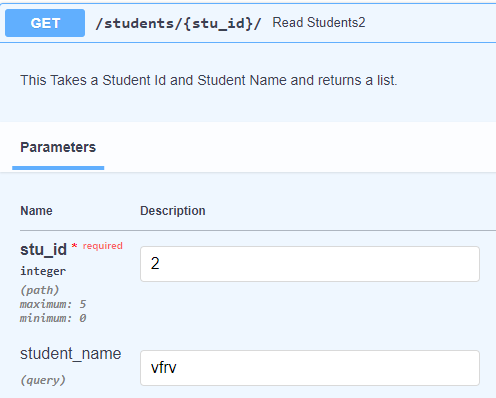

# **Pydantic Models**

**Request Body**

* Pydantics is commonly used as a resource for data validation and how to handle data coming to our FastAPI application.
* A request body is data sent by the client to your API.
* A response body is the data your API sends to the client.
* To declare a request body, you use Pydantic models with all their power and benefits.
* To use First, you need to import BaseModel from pydantic
              * from pydantic import BaseModel
* Then you declare your data model as a class that inherits from BaseModel.Here it is Student.
* The parameter provided would be of type Student which is a pydantic model.

In [ ]:
from fastapi import FastAPI
from pydantic import BaseModel


class Student(BaseModel):
    student_name: str
    student_id : int
    marks : int
    language : str

app = FastAPI()

@app.post("/create_req_student/")
async def create_stud(stu: Student):

   """
   Takes input as a pydantic model input and returns the student created.
   """

    return stu

* We can take input from user as in given pydantic model in the form of JSON.
* Request body will be provided as example and user can provide the details in the place of types.

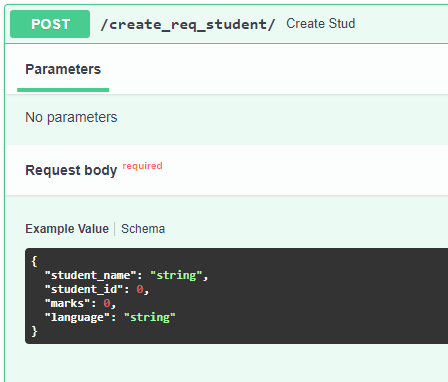

# **Field Parameters**

* The same way you can declare additional validation and metadata in path operation function parameters with Query, Path , you can declare validation and metadata inside of Pydantic models using Pydantic's Field.
* First, you have to import it:
                 * from pydantic import BaseModel, Field



In [ ]:
from pydantic import BaseModel, Field

app = FastAPI()

class Student(BaseModel):
    student_name: str
    student_id : int
    marks : int  = Field(gt=0, description="The marks needs to be less than 100")
    language : str | None = Field(default=None, title="The language student is interested in", max_length=20)

# **Body Parameters**

* The same way there is a Query and Path to define extra data for query and path parameters, FastAPI provides an equivalent Body
* Import Body from fastapi like :
                from fastapi import Body

In [ ]:
from fastapi import Body,FastAPI
from pydantics import BaseModel

app = FastAPI()

class Student(BaseModel):
    student_name: str
    student_id : int
    marks : int  = Field(gt=0, description="The marks needs to be less than 100")
    language : str | None = Field(default=None, title="The language student is interested in", max_length=20)

@app.put("/students/{stu_id}/")
async def data(stu_id: Annotated[int, Path(title="The ID of the student to get", ge=0, le=5)], s : Student,new: Annotated[str, Body()]):

    """
    Takes the student id and A pydantic student detail and new with a body.
    """
    
    results = {"Student id ":stu_id , "Student " : s,"New ": new}
    return results

* Below you can see the request body for both pydantic model and the Body() parameter.

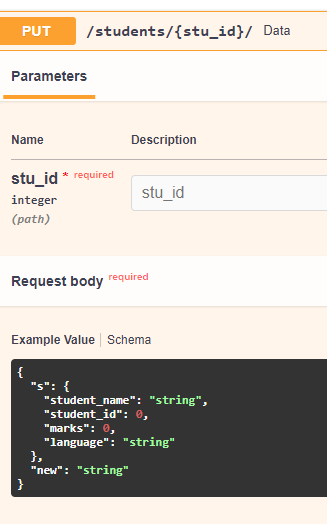

#**FILES**

**File Parameters**

* You can define files to be uploaded by the client using File.
* To recieve the uploaded files, we need to install :
                        * pip install python-multipart

In [ ]:
pip install python-multipart

* File parameters are defined the same way you would for Body,Path ,Query.
* Import File parameters like File and UploadFile like :
                     * from fastapi import File,UploadFile


**File and UploadFile**

* To declare File bodies, you need to use File, because otherwise the parameters would be interpreted as query parameters or body (JSON) parameters.

* UploadFile is a class in FastAPI designed to handle file uploads. It offers several benefits over using bytes or file types directly, including:

* Memory Efficiency: It stores the uploaded file in memory up to a certain size and, beyond that threshold, in a temporary file.
* Asynchronous File Support: It supports asynchronous reading and writing.
* Metadata Access: It allows access to file metadata such as filename and content type.

In [ ]:
from fastapi import FastAPI, File, UploadFile

app = FastAPI()

@app.post("/files/")
async def create_file(file: Annotated[bytes, File()]):

    """
    This takes file from user and returns the length of file.
    """

    return {"file_size": len(file)}

@app.post("/uploadfile/")
async def create_upload_file(file: UploadFile):

    """
    This takes file from user and returns the name and content_type of file.
    """

    return {"filename": file.filename , "content_type" : file.content_type}

* Below is the snippet for File post request and UploadFile will also be the same and you can check the same executing the shared python file.

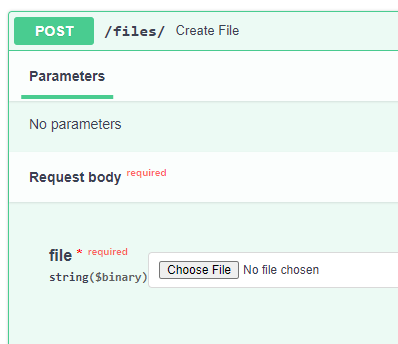

**Working with file content**

In [ ]:
@app.post("/processfile/")
async def process_file(file: UploadFile):

  """
  This takes the file from user and reads the content of file.
  """

  content = await file.read()

  return {"file_content": content}

* Below snippet shows the output when I have uploaded a file.As you can see it has Status Code as 200 -> Successful.

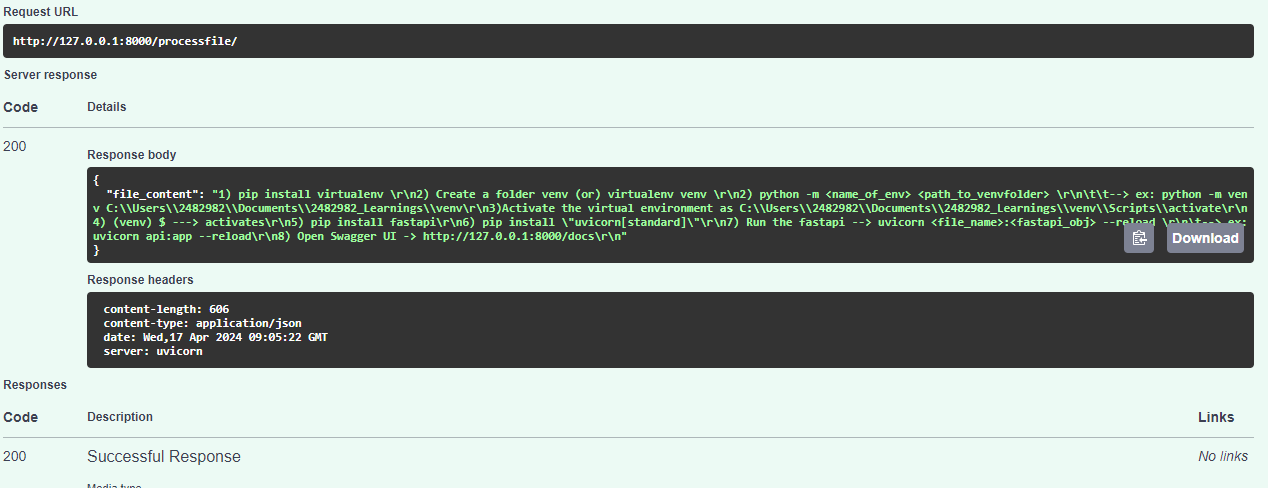

# **Integration with LLMs**

* FastAPI, with its performance and ease of use, provides a straightforward way to build high-performance APIs, making it an ideal choice for developers looking to integrate LLMs into their projects.
* LLMs have some settings like Temperature,maximum length,etc.And by providing a prompt(question) and a File to an LLM along with settings, llm models will fetch the response for the prompt from the data provided in the file and provide answer to the user.


In [ ]:
from fastapi import FastAPI,Path,Query,Body,File,UploadFile
from typing import Annotated

app=FastAPI()

@app.get("/question/")
async def get_answer(Temperature : int,
                 max_length : int,
                 prompt : Annotated[str, Body()],
                 user_file : Annotated[UploadFile ,File(description="A file read as UploadFile")]):
    """
    This takes Temperature,Maxlength,a question and File from User and provide the Output for the User.
    """
     #Response = Call a method that fetches the response using the file given by user and get the response.
     response = #llmFunctioncall(temperature,max_length,prompt,user_file)
     return response


* In LLMs , FastAPI helps users to provide files,prompt and their required settings to help LLM work and LLM will take care of all the fetching and response generation.
* And finally FastAPI returns the response given by LLM to User.

# **Status Codes**

* An HTTP Status Code is used to help the Client to understand what happened on the server side application.
* Status Codes are international standards on how a Client/Server should handle the result of a request.
* Main Status Codes are -->
                * 200 -> Successful Get requests and returns something.
                * 201 -> Successful, creating a new resource(POST)
                * 204 -> Successful , PUT request.
                * 400 -> Invalid Request Methods.
                * 401 -> Unauthorized.
                * 404 -> Resource was not found.
                * 500 -> Unexpected issue happend

In [ ]:
from fastapi import status
@app.post("/student/",status_code = status.HTTP_201_CREATED)
async def create_book(new = Body()):

    """
    This Takes a dict of an entire students and adds to Students list using Body()
    """

    Students.append(new)

In [ ]:
from fastapi import HTTPException

@app.delete("/delete_me/{stu_name}")
async def delete_student(stu_name: str):

    """
    This Takes a Student name and delete all students with that name.
    """

    for i in range(len(Students)):
        if stu_name.casefold()== Students[i].get("student_name").casefold():
            Students.pop(i)
            break
        else:
            raise HTTPException(status_code= 402, detail= "Name not Found")

EMBEDDING FILE CREATION

In [ ]:
@app.post("/embedding_call/")
async def embedding_call(

    fileb: Annotated[UploadFile, File()],
    domain_name: Annotated[str, Form()],
	user_name: Annotated[str, Form()],
	token_number: Annotated[str, Form()],
    model_name: Optional[str] = Form(None)):

    try:
        model_name = 'e5-large v2'

        if authentication(user_name,token_number):

            content = await fileb.read()
            file_name = fileb.filename
            staged_file = staging_call(domain_name, model_name, file_name)
            staged_file = staged_file.strip()
            Domain_name = "data_"+domain_name
            logger.info("Staged file recieved")
            root_path = config_loader().get("root_path")
            domain_folder = os.path.join(root_path,"data",Domain_name)
            output_file_path = os.path.join(domain_folder,staged_file)
            logger.info("Staged file placed inside domain folder.")

            with open(output_file_path, "wb") as file:
                file.write(content)  
            logger.info("Staged file created.")
            embedding.embedd(output_file_path)
            logger.info("Embedding file created.")
            
            return {"message" : "File Uploaded Successfully"}

        else:
            logger.error("401 Error Authentication Failed")
            raise HTTPException(status_code=401,detail="Authentication Failed")

    except Exception as e:
        raise HTTPException(status_code=400,detail="Bad request")